# Test results EDA — `test_results_27.csv`

Loads `test_results_27.csv` from the project root, parses `pcd_<n>` frame ids from `file_name`, and builds:

- **`df_frames`** — one row per partial scan (every potato × frame in the file).
- **`df_per_potato`** — per tuber: how many frames, min/max/**median** frame number, **median `exec_time_ms`** across frames.
- **`df_middle`** — one row per potato: the scan whose `frame_id` is **closest** to the median frame index for that potato (tie-break: smaller `frame_id`). Includes that row’s metrics plus **`median_exec_time_ms`** from `df_per_potato` for comparison.

In [7]:
from __future__ import annotations

from pathlib import Path
import pandas as pd

BASE = Path.cwd()
RESULT_PATH = BASE / "results/test_results_30.csv"

if not RESULT_PATH.is_file():
    raise FileNotFoundError(f"Missing {RESULT_PATH.resolve()}")

df_frames = pd.read_csv(RESULT_PATH)

m = df_frames["file_name"].astype(str).str.extract(r"pcd_(\d+)\.ply", expand=False)
if m.isna().any():
    bad = df_frames.loc[m.isna(), "file_name"].head(5).tolist()
    raise ValueError(f"Could not parse frame id from file_name (examples): {bad}")
df_frames["frame_id"] = m.astype(int)

df_frames = df_frames.sort_values(["unique_id", "frame_id"], kind="mergesort").reset_index(
    drop=True
)

# Show the median exec_time_ms over all rows, not per unique_id
median_exec_time_all = df_frames["exec_time_ms"].median()

print(f"Median exec_time_ms over all rows: {median_exec_time_all:.2f} ms")

Median exec_time_ms over all rows: 13.82 ms


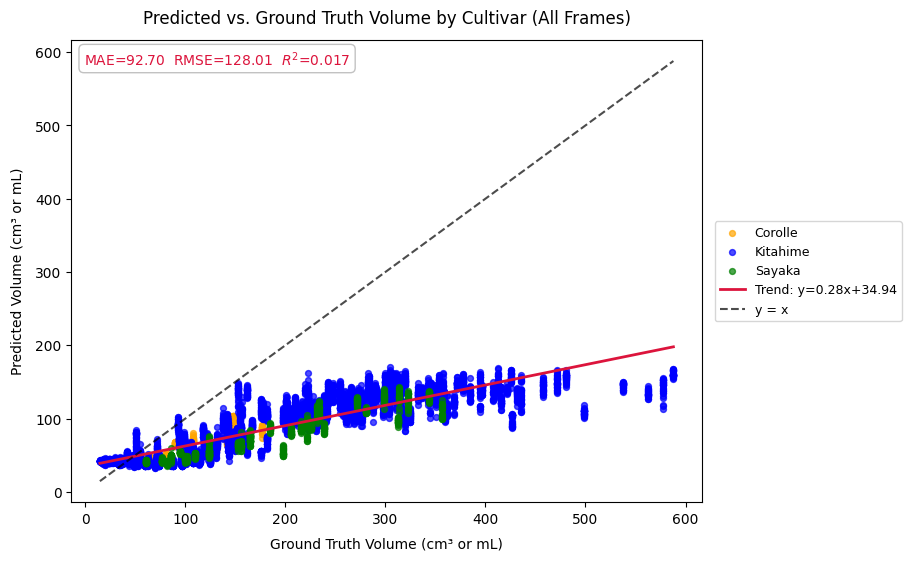

In [10]:
import matplotlib.pyplot as plt
from __future__ import annotations

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

BASE = Path.cwd()
RESULT_PATH = BASE / "results/test_results_30.csv"

if not RESULT_PATH.is_file():
    raise FileNotFoundError(f"Missing {RESULT_PATH.resolve()}")

df_frames = pd.read_csv(RESULT_PATH)

cultivars = sorted(df_frames["cultivar"].dropna().unique())
custom_colors = ["orange", "blue", "green"]
colors = custom_colors[:len(cultivars)]

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)

for i, cultivar in enumerate(cultivars):
    mask = df_frames["cultivar"] == cultivar
    ax.scatter(
        df_frames.loc[mask, "gt_volume_ml"],
        df_frames.loc[mask, "pred_volume_ml"],
        s=18,
        alpha=0.7,
        color=colors[i % len(colors)],
        label=str(cultivar)
    )

# Fit trend line (linear regression) on the true (gt_volume_ml, pred_volume_ml) pairs
X = df_frames["gt_volume_ml"].values.reshape(-1, 1)
y = df_frames["pred_volume_ml"].values
reg = LinearRegression().fit(X, y)

# Only use the regression result for the trend line and for the *metrics on the actual predictions*
# For error metrics, use the actual predictions (i.e., true vs predicted, not trend-fitted values)
# Compute regression line (trend) to plot
x_fit = np.array([df_frames["gt_volume_ml"].min(), df_frames["gt_volume_ml"].max()]).reshape(-1, 1)
y_fit = reg.predict(x_fit)
ax.plot(x_fit.flatten(), y_fit, color="crimson", lw=2, linestyle="-", label=f"Trend: y={reg.coef_[0]:.2f}x+{reg.intercept_:.2f}")

# Also plot the y=x identity line for comparison
vmin = df_frames["gt_volume_ml"].min()
vmax = df_frames["gt_volume_ml"].max()
ax.plot([vmin, vmax], [vmin, vmax], color='k', linestyle='--', alpha=0.7, label="y = x")

# Compute regression error metrics *between actual ground truth and predictions*, NOT trend values
mae = mean_absolute_error(df_frames["gt_volume_ml"].values, df_frames["pred_volume_ml"].values)
mse = mean_squared_error(df_frames["gt_volume_ml"].values, df_frames["pred_volume_ml"].values)
rmse = np.sqrt(mse)
r2 = r2_score(df_frames["gt_volume_ml"].values, df_frames["pred_volume_ml"].values)
metrics_text = f"MAE={mae:.2f}  RMSE={rmse:.2f}  $R^2$={r2:.3f}"

# Upper-left: usually clear on a y≈x scatter; keeps clear of legend (outside right)
ax.text(
    0.02,
    0.98,
    metrics_text,
    transform=ax.transAxes,
    fontsize=10,
    color="crimson",
    verticalalignment="top",
    horizontalalignment="left",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.95, edgecolor="0.75"),
)

ax.set_xlabel("Ground Truth Volume (cm³ or mL)", labelpad=8)
ax.set_ylabel("Predicted Volume (cm³ or mL)", labelpad=8)
ax.set_title("Predicted vs. Ground Truth Volume by Cultivar (All Frames)", pad=12)

# Outside plot on the right; constrained_layout reserves space for the legend
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
    frameon=True,
    fontsize=9,
)

plt.show()

Partial axis flip (pre-PCA): (-1, 1, -1)  |  median dist partial->full: 1.57 mm


C:\Users\Jesper\AppData\Local\Temp\ipykernel_2648\3190581153.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


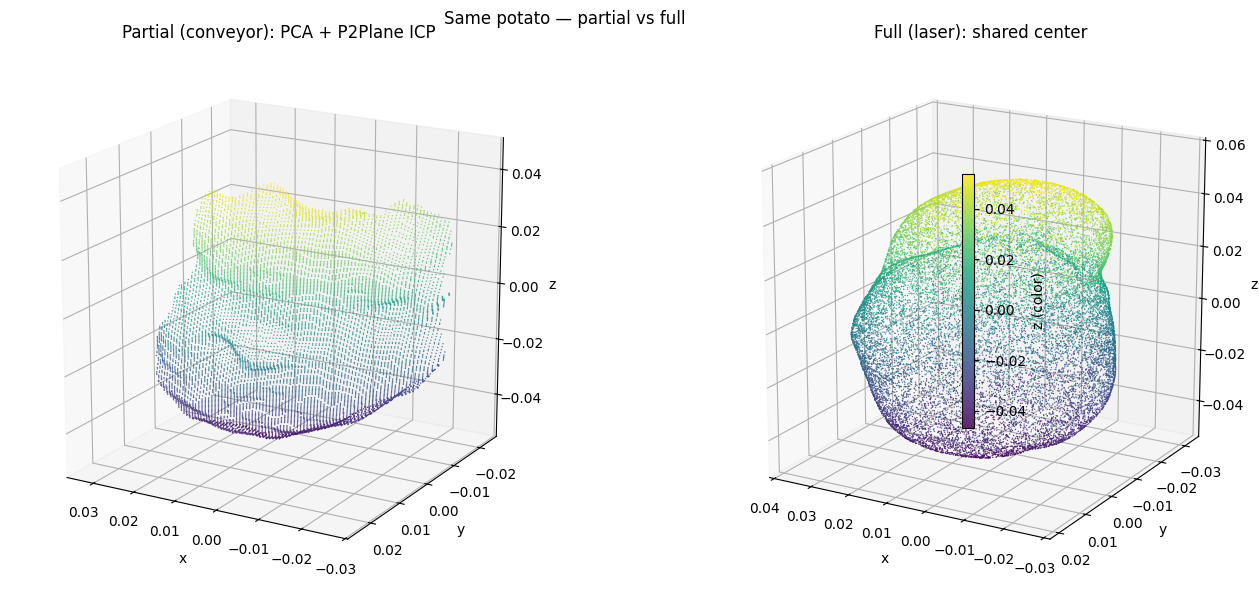

In [11]:
# Partial vs full point cloud — put matching `.ply` files next to this notebook and edit paths below.
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d

ROOT = Path(".").resolve()
PLY_PARTIAL = ROOT / "reviewdata/2025-000_pcd_355.ply"
PLY_FULL = ROOT / "reviewdata/2025-000_20000.ply"

pcd_partial_raw = o3d.io.read_point_cloud(str(PLY_PARTIAL))
pcd_full_raw = o3d.io.read_point_cloud(str(PLY_FULL))


def _pca_rotation_matrix(pts_p: np.ndarray, pts_f: np.ndarray) -> np.ndarray:
    _, _, v_partial = np.linalg.svd(pts_p, full_matrices=False)
    _, _, v_full = np.linalg.svd(pts_f, full_matrices=False)
    axes_p = v_partial.T
    axes_f = v_full.T
    r = axes_f @ axes_p.T
    if np.linalg.det(r) < 0:
        axes_f = axes_f.copy()
        axes_f[:, 2] *= -1
        r = axes_f @ axes_p.T
    return r


def _multiscale_point_to_plane_icp(
    pcd_source: o3d.geometry.PointCloud,
    pcd_target: o3d.geometry.PointCloud,
    extent: float,
) -> np.ndarray:
    """Coarse-to-fine point-to-plane ICP (surface alignment)."""
    voxel_base = max(extent * 0.03, 0.002)
    voxels = [voxel_base * 3.5, voxel_base * 1.8, voxel_base]
    max_iters = [60, 45, 35]
    trans = np.eye(4)
    for vox, mx in zip(voxels, max_iters):
        src = pcd_source.voxel_down_sample(vox)
        tgt = pcd_target.voxel_down_sample(vox)
        src.estimate_normals(
            o3d.geometry.KDTreeSearchParamHybrid(radius=vox * 2.5, max_nn=40)
        )
        tgt.estimate_normals(
            o3d.geometry.KDTreeSearchParamHybrid(radius=vox * 2.5, max_nn=40)
        )
        th = vox * 4.0
        reg = o3d.pipelines.registration.registration_icp(
            src,
            tgt,
            th,
            trans,
            o3d.pipelines.registration.TransformationEstimationPointToPlane(),
            o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=mx),
        )
        trans = reg.transformation
    return trans


def _median_distance_to_target(
    pcd_source: o3d.geometry.PointCloud, pcd_target: o3d.geometry.PointCloud
) -> float:
    d = np.asarray(pcd_source.compute_point_cloud_distance(pcd_target))
    return float(np.median(d))


def _align_one_flip(
    pcd_p_in: o3d.geometry.PointCloud,
    pcd_f_in: o3d.geometry.PointCloud,
    partial_flip: np.ndarray,
) -> tuple[o3d.geometry.PointCloud, o3d.geometry.PointCloud, float]:
    pts_p = (np.asarray(pcd_p_in.points) - np.asarray(pcd_p_in.points).mean(axis=0)) * partial_flip
    pts_f = np.asarray(pcd_f_in.points) - np.asarray(pcd_f_in.points).mean(axis=0)
    r = _pca_rotation_matrix(pts_p, pts_f)
    pts_p = pts_p @ r.T

    pcd_p = o3d.geometry.PointCloud()
    pcd_p.points = o3d.utility.Vector3dVector(pts_p)
    if pcd_p_in.has_colors():
        pcd_p.colors = pcd_p_in.colors
    pcd_f = o3d.geometry.PointCloud()
    pcd_f.points = o3d.utility.Vector3dVector(pts_f)
    if pcd_f_in.has_colors():
        pcd_f.colors = pcd_f_in.colors

    extent = max(np.ptp(pts_p, axis=0).max(), np.ptp(pts_f, axis=0).max())
    trans_icp = _multiscale_point_to_plane_icp(pcd_p, pcd_f, extent)
    pcd_p.transform(trans_icp)

    med = _median_distance_to_target(pcd_p, pcd_f)
    return pcd_p, pcd_f, med


def register_partial_to_full(
    pcd_partial: o3d.geometry.PointCloud, pcd_full: o3d.geometry.PointCloud
) -> tuple[np.ndarray, np.ndarray]:
    """Pick axis flip by lowest median partial->full distance; align with PCA + P2Plane ICP only."""
    best_med = None
    best_flip = None
    for sx in (-1.0, 1.0):
        for sy in (-1.0, 1.0):
            for sz in (-1.0, 1.0):
                flip = np.array([sx, sy, sz])
                _, _, med = _align_one_flip(
                    deepcopy(pcd_partial),
                    deepcopy(pcd_full),
                    flip,
                )
                if best_med is None or med < best_med:
                    best_med = med
                    best_flip = flip.copy()

    assert best_flip is not None
    pcd_p, pcd_f, med_final = _align_one_flip(pcd_partial, pcd_full, best_flip)

    pts_p = np.asarray(pcd_p.points)
    pts_f = np.asarray(pcd_f.points)
    center = np.vstack([pts_p, pts_f]).mean(axis=0)
    pts_p -= center
    pts_f -= center

    print(
        f"Partial axis flip (pre-PCA): ({best_flip[0]:.0f}, {best_flip[1]:.0f}, {best_flip[2]:.0f})  |  "
        f"median dist partial->full: {med_final*1000:.2f} mm"
    )
    return pts_p, pts_f


pts_partial_c, pts_full_c = register_partial_to_full(pcd_partial_raw, pcd_full_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "3d"})
titles = (
    "Partial (conveyor): PCA + P2Plane ICP",
    "Full (laser): shared center",
)
sc = None
elev, azim = 18, 120
for ax, pts, title in zip(axes, (pts_partial_c, pts_full_c), titles):
    sc = ax.scatter(
        pts[:, 0],
        pts[:, 1],
        pts[:, 2],
        c=pts[:, 2],
        cmap="viridis",
        s=1.0,
        alpha=0.85,
        linewidths=0,
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=elev, azim=azim)
fig.colorbar(sc, ax=axes, shrink=0.55, label="z (color)")
fig.suptitle("Same potato — partial vs full")
plt.tight_layout()
plt.show()


In [4]:
# Interactive 3D (rotate / zoom / pan) — requires: pip install open3d plotly
# Run the cell above first: it defines pts_partial_c / pts_full_c (P2Plane + color ICP + shared center).
import numpy as np
import open3d as o3d

if "pts_partial_c" not in globals() or "pts_full_c" not in globals():
    raise RuntimeError("Run the previous cell first so the two clouds are registered and centered together.")

def numpy_to_pcd(pts: np.ndarray, color_rgb: tuple[float, float, float]) -> o3d.geometry.PointCloud:
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    n = pts.shape[0]
    cols = np.tile(np.array(color_rgb, dtype=np.float64), (n, 1))
    pcd.colors = o3d.utility.Vector3dVector(cols)
    return pcd


pcd_p = numpy_to_pcd(pts_partial_c, (1.0, 0.45, 0.1))
pcd_f = numpy_to_pcd(pts_full_c, (0.2, 0.5, 0.95))

# Both clouds in one Plotly scene — use the toolbar to orbit / zoom / reset camera
o3d.visualization.draw_plotly(
    [pcd_p, pcd_f],
    window_name="R9-9 partial (orange) vs full (blue)",
    width=950,
    height=700,
    point_sample_factor=1.0,
)

# Optional: native Open3D window (separate desktop window, full rendering controls)
# o3d.visualization.draw_geometries([pcd_p, pcd_f], window_name="R9-9", width=1280, height=720)


Frames per group:
group
Corolle (2023)      291
Kitahime (2023)     265
Sayaka (2023)       869
Kitahime (2025)    8201


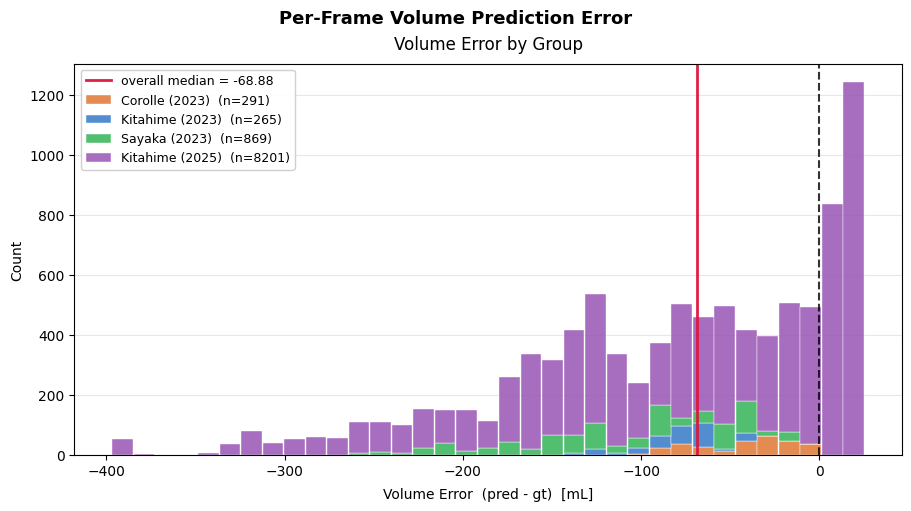

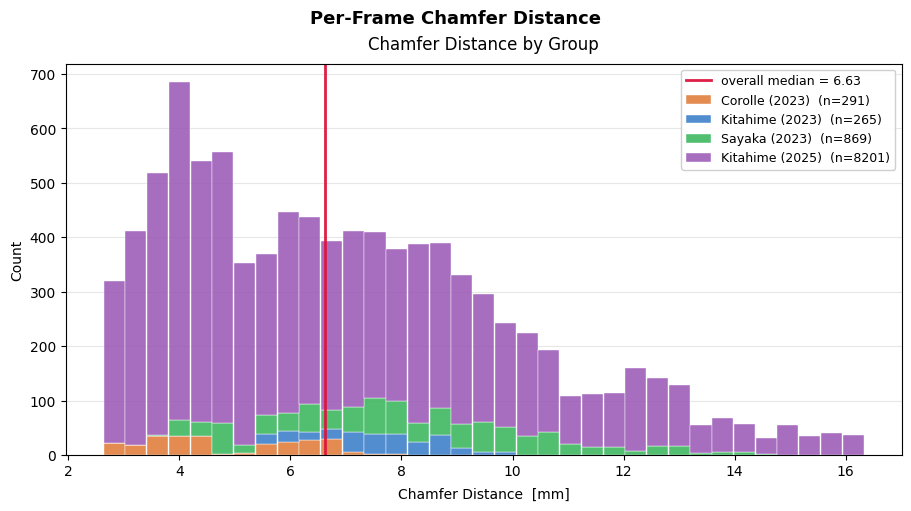


                vol_error                  chamfer_mm              
                     mean  median      std       mean median    std
group                                                              
Corolle (2023)    -41.106 -35.710   26.884      4.508  4.208  1.598
Kitahime (2023)   -79.478 -74.247   22.746      7.546  7.534  1.084
Sayaka (2023)    -110.829 -99.449   59.104      8.101  7.923  2.399
Kitahime (2025)   -85.055 -64.331  100.120      7.104  6.456  3.342


In [12]:
# Error histograms -- volume error (pred - gt) and Chamfer distance
# Four fixed groups: Corolle 2023 / Kitahime 2023 / Sayaka 2023 / Kitahime 2025
# One frame = one data point (no per-potato aggregation).
#
# Assumes df_frames is already loaded (run cell 2 first).

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build a combined group label from cultivar + year
df = df_frames.copy()
df["vol_error"] = df["pred_volume_ml"] - df["gt_volume_ml"]
df["group"] = (df["cultivar"].astype(str).str.strip()
               + " (" + df["year"].astype(str).str.strip() + ")")

GROUPS  = ["Corolle (2023)", "Kitahime (2023)", "Sayaka (2023)", "Kitahime (2025)"]
PALETTE = ["#E07B39", "#3A7EC9", "#3AB55C", "#9B59B6"]
ALPHA   = 0.88
N_BINS  = 35

df = df[df["group"].isin(GROUPS)]
print("Frames per group:")
print(df["group"].value_counts().reindex(GROUPS).to_string())


def _stacked_hist(ax, metric_col, xlabel, zero_line):
    all_vals = df[metric_col].dropna().values
    lo = np.nanpercentile(all_vals, 1)
    hi = np.nanpercentile(all_vals, 99)
    bins = np.linspace(lo, hi, N_BINS + 1)

    vals_list = [
        df.loc[df["group"] == g, metric_col].dropna().values
        for g in GROUPS
    ]
    counts = np.array([np.histogram(v, bins=bins)[0] for v in vals_list], dtype=float)

    bottoms = np.zeros(len(bins) - 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bar_width = bins[1] - bins[0]

    for i, (group, color) in enumerate(zip(GROUPS, PALETTE)):
        ax.bar(
            bin_centers, counts[i], width=bar_width * 0.97,
            bottom=bottoms, color=color, alpha=ALPHA,
            label=f"{group}  (n={len(vals_list[i])})",
            edgecolor="white", linewidth=0.35,
        )
        bottoms += counts[i]

    if zero_line:
        ax.axvline(0, color="black", linestyle="--", lw=1.5, alpha=0.8)

    med = np.nanmedian(all_vals)
    ax.axvline(med, color="crimson", linestyle="-", lw=2.0, alpha=0.95,
               label=f"overall median = {med:.2f}")

    ax.set_xlabel(xlabel, labelpad=6)
    ax.set_ylabel("Count")
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, framealpha=0.92)


# Volume error histogram
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
_stacked_hist(ax, "vol_error", "Volume Error  (pred - gt)  [mL]", zero_line=True)
ax.set_title("Volume Error by Group", pad=10)
fig.suptitle("Per-Frame Volume Prediction Error", fontsize=13, fontweight="bold")
plt.show()

# Chamfer distance histogram
if "chamfer_mm" in df.columns:
    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    _stacked_hist(ax, "chamfer_mm", "Chamfer Distance  [mm]", zero_line=False)
    ax.set_title("Chamfer Distance by Group", pad=10)
    fig.suptitle("Per-Frame Chamfer Distance", fontsize=13, fontweight="bold")
    plt.show()

# Summary table
stat_cols = [c for c in ("vol_error", "chamfer_mm") if c in df.columns]
print()
print(df.groupby("group")[stat_cols].agg(["mean", "median", "std"])
      .reindex(GROUPS).round(3).to_string())


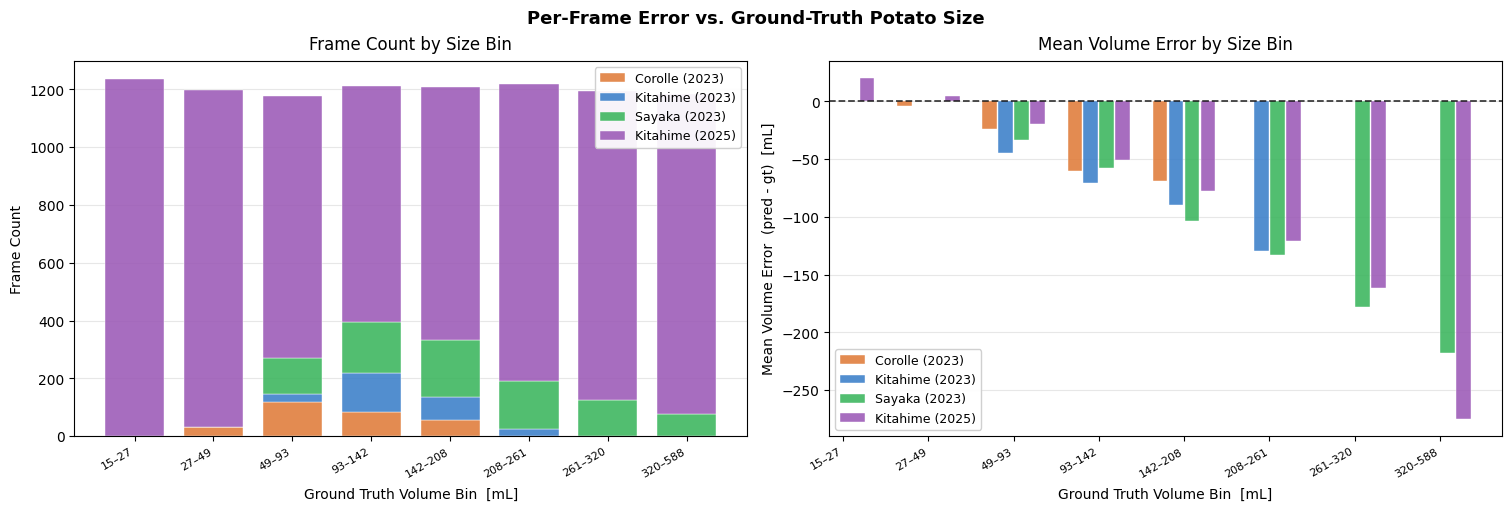

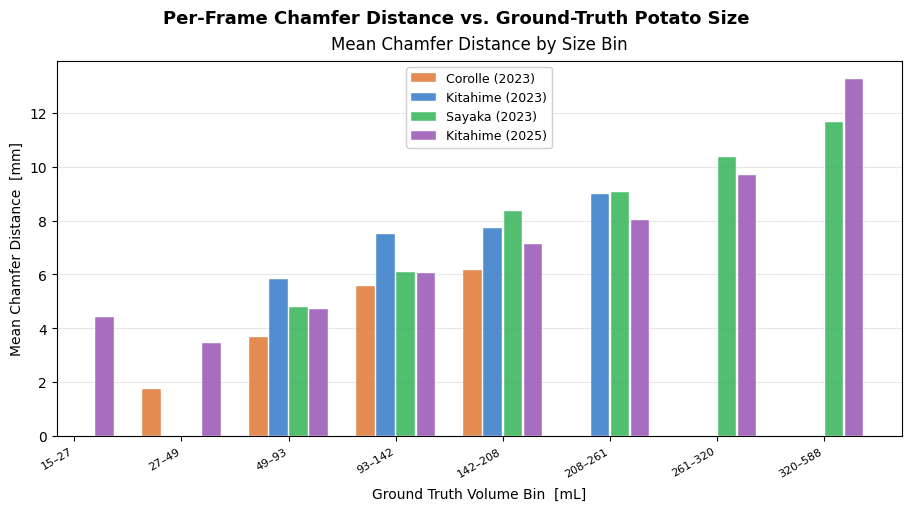

In [13]:
# Same four groups, but x-axis = ground-truth size bins instead of error values.
# Stacked bars show how many frames fall in each size bucket (size distribution).
# Grouped line+marker overlay shows mean error / mean chamfer per size bin.
#
# Assumes df and GROUPS / PALETTE are defined (run the cell above first).

import matplotlib.pyplot as plt
import numpy as np

N_SIZE_BINS = 8

# Build size bins from the gt_volume_ml distribution
bin_edges = np.percentile(df['gt_volume_ml'].dropna(), np.linspace(0, 100, N_SIZE_BINS + 1))
bin_edges = np.unique(bin_edges)  # drop duplicates at the tails
bin_labels = [
    f"{bin_edges[i]:.0f}–{bin_edges[i+1]:.0f}"
    for i in range(len(bin_edges) - 1)
]

df['size_bin'] = pd.cut(
    df['gt_volume_ml'],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True,
)

x = np.arange(len(bin_labels))
bar_w = 0.75


def _size_stacked_count(ax):
    """Stacked bar: count of frames per size bin, coloured by group."""
    bottoms = np.zeros(len(bin_labels))
    for group, color in zip(GROUPS, PALETTE):
        counts = (
            df[df['group'] == group]
            .groupby('size_bin', observed=True)
            .size()
            .reindex(bin_labels, fill_value=0)
            .values
            .astype(float)
        )
        ax.bar(x, counts, width=bar_w, bottom=bottoms,
               color=color, alpha=0.88,
               label=group, edgecolor='white', linewidth=0.35)
        bottoms += counts
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=30, ha='right', fontsize=8)
    ax.set_xlabel('Ground Truth Volume Bin  [mL]', labelpad=6)
    ax.set_ylabel('Frame Count')
    ax.set_title('Frame Count by Size Bin', pad=8)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, framealpha=0.92)


def _size_mean_metric(ax, metric_col, ylabel, zero_line):
    """Grouped bars: mean metric per size bin, one bar group per cultivar/year group."""
    n_groups = len(GROUPS)
    group_w = bar_w / n_groups
    offsets = np.linspace(-(bar_w - group_w) / 2,
                          (bar_w - group_w) / 2, n_groups)
    for group, color, offset in zip(GROUPS, PALETTE, offsets):
        means = (
            df[df['group'] == group]
            .groupby('size_bin', observed=True)[metric_col]
            .mean()
            .reindex(bin_labels)
            .values
        )
        ax.bar(x + offset, means, width=group_w * 0.92,
               color=color, alpha=0.88,
               label=group, edgecolor='white', linewidth=0.35)
    if zero_line:
        ax.axhline(0, color='black', linestyle='--', lw=1.3, alpha=0.75)
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=30, ha='right', fontsize=8)
    ax.set_xlabel('Ground Truth Volume Bin  [mL]', labelpad=6)
    ax.set_ylabel(ylabel)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, framealpha=0.92)


# Figure 1: count distribution + mean volume error
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
_size_stacked_count(axes[0])
_size_mean_metric(axes[1], 'vol_error',
                  'Mean Volume Error  (pred - gt)  [mL]', zero_line=True)
axes[1].set_title('Mean Volume Error by Size Bin', pad=8)
fig.suptitle('Per-Frame Error vs. Ground-Truth Potato Size',
             fontsize=13, fontweight='bold')
plt.show()

# Figure 2: mean chamfer distance by size bin
if 'chamfer_mm' in df.columns:
    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    _size_mean_metric(ax, 'chamfer_mm',
                      'Mean Chamfer Distance  [mm]', zero_line=False)
    ax.set_title('Mean Chamfer Distance by Size Bin', pad=8)
    fig.suptitle('Per-Frame Chamfer Distance vs. Ground-Truth Potato Size',
                 fontsize=13, fontweight='bold')
    plt.show()


## Encoder Input Visualisation

Shows what point clouds look like at each pre-processing stage before entering the encoder:
1. **Raw** — points loaded directly from the `.ply` file
2. **Centred** — mean subtracted (the only normalisation applied)
3. **FPS 1024** — farthest-point sampled to 1024 points

Set `PLY_PATH` to any `.ply` from the dataset. Run on the GPU server where `torch_fpsample` is available.

In [28]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d

ROOT = Path(".").resolve()
PLY_PARTIAL = ROOT / "reviewdata/R9-9_pcd_365.ply"
PLY_FULL = ROOT / "reviewdata/2025-000_20000.ply"

# Config — set to any .ply from the 3DPotatoTwin dataset
# ---------------------------------------------------------------------------
PLY_PATH = PLY_PARTIAL  # e.g. "/data/3DPotatoTwin/1_rgbd/2_pcd/label123/label123_pcd_05.ply"
NUM_POINTS = 1024
N_AUGMENTED_VARIANTS = 3   # number of augmented versions to show in the second row
POINT_SIZE = 2

if not PLY_PATH:
    raise ValueError("Set PLY_PATH to a .ply file from the dataset before running this cell.")

# ---------------------------------------------------------------------------
# Pre-processing (mirrors encoder_dataset.py exactly)
# ---------------------------------------------------------------------------
pcd = o3d.io.read_point_cloud(PLY_PATH)
raw = np.asarray(pcd.points, dtype=np.float32)

centred = raw - raw.mean(axis=0)

# FPS — use torch_fpsample if available (server), else random subsample (local)
pts_t = torch.tensor(centred, dtype=torch.float32)
try:
    import torch_fpsample
    fps_pts, _ = torch_fpsample.sample(pts_t, min(NUM_POINTS, pts_t.shape[0]))
    fps = fps_pts.numpy()
    fps_label = f"FPS {NUM_POINTS}"
except ImportError:
    rng_fps = np.random.default_rng(0)
    idx = rng_fps.choice(len(centred), min(NUM_POINTS, len(centred)), replace=False)
    fps = centred[idx]
    fps_label = f"Random subsample {NUM_POINTS} (no torch_fpsample)"


# Recompute augmented variants to have the same scale and bbox
def _augment(pts: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    rx = math.radians(rng.uniform(-2, 2))
    ry = math.radians(rng.uniform(-2, 2))
    rz = math.radians(rng.uniform(-90, 90))
    cx, sx = math.cos(rx), math.sin(rx)
    cy, sy = math.cos(ry), math.sin(ry)
    cz, sz = math.cos(rz), math.sin(rz)
    Rx = np.array([[1, 0, 0], [0, cx, -sx], [0, sx, cx]], dtype=np.float32)
    Ry = np.array([[cy, 0, sy], [0, 1, 0], [-sy, 0, cy]], dtype=np.float32)
    Rz = np.array([[cz, -sz, 0], [sz, cz, 0], [0, 0, 1]], dtype=np.float32)
    pts = pts @ (Rz @ Ry @ Rx).T
    if rng.random() < 0.5:
        pts[:, 0] = -pts[:, 0]
    noise = rng.standard_normal(pts.shape).astype(np.float32) * 5e-4
    noise = np.clip(noise, -1e-3, 1e-3)
    pts = pts + noise
    return pts

rng = np.random.default_rng(42)
augmented_variants = [_augment(fps.copy(), rng) for _ in range(N_AUGMENTED_VARIANTS)]

# ---------------------------------------------------------------------------
# Interactive plotly figure  (rotate / zoom / pan each subplot independently)
# ---------------------------------------------------------------------------
n_cols = max(3, N_AUGMENTED_VARIANTS)
n_rows = 2

specs = [[ {"type": "scatter3d"} for _ in range(n_cols)] for _ in range(n_rows)]
row1_titles = [
    f"1. Raw ({len(raw):,} pts)",
    f"2. Centred ({len(centred):,} pts)",
    f"3. {fps_label} ({len(fps):,} pts)",
] + [""] * (n_cols - 3)
row2_titles = [f"4. Augmented variant {i+1}" for i in range(N_AUGMENTED_VARIANTS)] \
              + [""] * (n_cols - N_AUGMENTED_VARIANTS)
subplot_titles = row1_titles + row2_titles

fig = make_subplots(
    rows=n_rows, cols=n_cols,
    specs=specs,
    subplot_titles=subplot_titles,
    horizontal_spacing=0.02,
    vertical_spacing=0.06,
)

BLUE   = "#4C72B0"
ORANGE = "#DD8452"

def _trace(pts: np.ndarray, color: str, name: str) -> go.Scatter3d:
    return go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode="markers",
        marker=dict(size=POINT_SIZE, color=color, opacity=0.7),
        name=name,
        showlegend=False,
        hovertemplate="x=%{x:.4f} m<br>y=%{y:.4f} m<br>z=%{z:.4f} m<extra></extra>",
    )

for col_i, (pts, name) in enumerate([
    (raw,     f"Raw ({len(raw):,} pts)"),
    (centred, f"Centred ({len(centred):,} pts)"),
    (fps,     f"{fps_label} ({len(fps):,} pts)"),
], start=1):
    fig.add_trace(_trace(pts, BLUE, name), row=1, col=col_i)

for i, aug in enumerate(augmented_variants):
    fig.add_trace(
        _trace(aug, ORANGE, f"Augmented variant {i+1}"),
        row=2, col=i + 1,
    )

axis_style = dict(
    showbackground=True,
    backgroundcolor="rgb(240,240,240)",
    gridcolor="white",
    title_font_size=9,
)
scene_kw = dict(
    xaxis={**axis_style, "title": "X (m)", "range": [-0.15, 0.15]},
    yaxis={**axis_style, "title": "Y (m)", "range": [-0.15, 0.15]},
    zaxis={**axis_style, "title": "Z (m)", "range": [-0.15, 0.15]},
    aspectmode="data",
)

scene_idx = 1
for r in range(1, n_rows + 1):
    for c in range(1, n_cols + 1):
        key = "scene" if scene_idx == 1 else f"scene{scene_idx}"
        fig.update_layout(**{key: scene_kw})
        scene_idx += 1

fig.update_layout(
    title_text=f"Encoder pre-processing  |  {Path(PLY_PATH).name}",
    title_font_size=14,
    height=750,
    margin=dict(l=0, r=0, t=60, b=0),
)

fig.show()

# Summary statistics
print(f"\nRaw     — n={len(raw):>6,}  bbox X={(raw[:,0].max()-raw[:,0].min()):.4f} m  Y={(raw[:,1].max()-raw[:,1].min()):.4f} m  Z={(raw[:,2].max()-raw[:,2].min()):.4f} m")
print(f"Centred — centroid={centred.mean(axis=0).round(6)}")
print(f"FPS     — n={len(fps):>6,}  bbox X={(fps[:,0].max()-fps[:,0].min()):.4f} m  Y={(fps[:,1].max()-fps[:,1].min()):.4f} m  Z={(fps[:,2].max()-fps[:,2].min()):.4f} m")



Raw     — n=10,972  bbox X=0.0537 m  Y=0.0583 m  Z=0.0280 m
Centred — centroid=[-0.e+00 -0.e+00  1.e-06]
FPS     — n= 1,024  bbox X=0.0523 m  Y=0.0576 m  Z=0.0270 m
